# PMT Processing Analysis Notes

This notebook processes segmented PMT oscilloscope waveforms. The workflow is: load all waveform segments, align their time axes, subtract the pre-pulse baseline, optionally filter high-frequency noise, find pulse-height and charge observables, apply simple pulse-selection cuts, and summarize the accepted-pulse statistics.

The pulse-height cut is a simple diagnostic selection: the notebook estimates the average baseline RMS noise and accepts pulses with height larger than `THRESHOLD_SIGMA * sigma_mean`. This is not a full statistical model of the pedestal or photoelectron spectrum.


In [35]:
import os
import numpy as np
import matplotlib.pyplot as plt

## Data Input and Processing Functions

The data path and file list define which segmented oscilloscope text files are analyzed. `processing_files` splits each file into individual waveform segments when the time column resets. The utility functions then normalize time, subtract the baseline, optionally filter the waveform, calculate pulse observables, and estimate waveform durations.


In [36]:
data_folder = os.path.expanduser("/Volumes/Untitled/Dark/900")
target_files = [f"C1C1{str(i).zfill(5)}.txt" for i in range(1, 100)]

R_TERMINATION = 50.0          # Oscilliscope termination, measured in Ohms
T_PRE_SIGNAL = 20e-9          # seconds, pre-pulse region for baseline/sigma
PULSE_START_TIME = 20e-9      # seconds, start of pulse integration window
THRESHOLD_SIGMA = 5.0         # threshold = 5 sigma figured this is a good cut off
APPLY_FILTER = True           # the FFT wasnt working so I messed with some stuff. This just turns it off
F_CUTOFF = 1e9                # Hz low-pass cutoff flexible
N_EXAMPLE_PLOTS = 5           # I kept changing how many I wanted to see

# -----------------------------
# Utilities
# -----------------------------
def processing_files(filepath):
    data = np.loadtxt(filepath, delimiter=",", usecols=(0, 1), skiprows=504)
    times = data[:, 0]
    amps = data[:, 1]

    waveforms = []
    current_t = []
    current_a = []

    for i in range(len(times)):
        if i > 0 and times[i] < times[i - 1]:
            waveforms.append((np.array(current_t), np.array(current_a)))
            current_t = []
            current_a = []

        current_t.append(times[i])
        current_a.append(amps[i])

    if current_t:
        waveforms.append((np.array(current_t), np.array(current_a)))

    return waveforms


def normalize_waveform_times(waveforms):
    normed = []
    for t, v in waveforms:
        normed.append((t - t[0], v))
    return normed


def subtract_baseline(waveforms, t_pre_signal=20e-9):
    corrected = []
    baselines = []
    sigmas = []

    for t, v in waveforms:
        mask = t < t_pre_signal

        if np.sum(mask) < 2:
            mask = np.arange(min(10, len(t)))

        baseline = np.mean(v[mask])
        sigma = np.std(v[mask], ddof=1) if np.sum(mask) > 1 else np.std(v[mask])

        corrected.append((t, v - baseline))
        baselines.append(baseline)
        sigmas.append(sigma)

    return corrected, np.array(baselines), np.array(sigmas)


def lowpass_filter_waveform(t, v, f_cut):
    if len(t) < 2:
        return v.copy()

    dt = np.mean(np.diff(t))
    freqs = np.fft.rfftfreq(len(v), d=dt)
    fft_vals = np.fft.rfft(v)

    fft_vals[freqs > f_cut] = 0.0
    v_filt = np.fft.irfft(fft_vals, n=len(v))
    return v_filt


def filter_waveforms(waveforms, f_cut=1e9):
    filtered = []
    for t, v in waveforms:
        filtered.append((t, lowpass_filter_waveform(t, v, f_cut)))
    return filtered


def extract_observables(waveforms, sigmas, pulse_start_time=20e-9, R=50.0):
    H_list = []
    Q_list = []
    sigma_list = []

    for (t, v), sigma in zip(waveforms, sigmas):
        H = -np.min(v)

        mask = t > pulse_start_time
        if np.sum(mask) < 2:
            Q = np.nan
        else:
            Q = (1.0 / R) * np.trapezoid(-v[mask], t[mask])

        H_list.append(H)
        Q_list.append(Q)
        sigma_list.append(sigma)

    return np.array(H_list), np.array(Q_list), np.array(sigma_list)


def waveform_duration(waveforms):
    durations = []
    for t, _ in waveforms:
        if len(t) > 1:
            durations.append(t[-1] - t[0])
    return np.array(durations)


# -----------------------------
# Load all waveforms
# -----------------------------
all_waveforms = []

for fname in target_files:
    filepath = os.path.join(data_folder, fname)
    if os.path.exists(filepath):
        file_waveforms = processing_files(filepath)
        all_waveforms.extend(file_waveforms)
    else:
        print(f"Missing file: {filepath}")

print(f"Total waveforms loaded: {len(all_waveforms)}")

Total waveforms loaded: 49500


## Raw Waveform Check

This first plot shows one unprocessed waveform segment. Use it to verify that the file is being read correctly and that the voltage polarity and timing look reasonable before trusting later cuts.


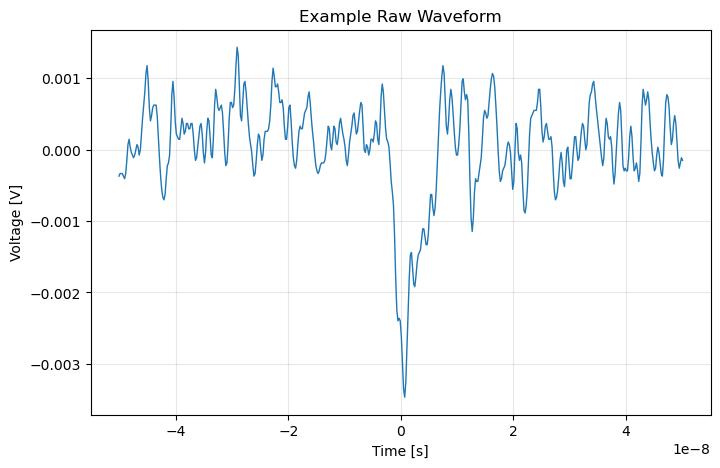

In [37]:
# -----------------------------
# Step 1: Plot one raw waveform
# -----------------------------
t0, v0 = all_waveforms[0]

plt.figure(figsize=(8, 5))
plt.plot(t0, v0, lw=1)
plt.xlabel("Time [s]")
plt.ylabel("Voltage [V]")
plt.title("Example Raw Waveform")
plt.grid(True, alpha=0.3)
plt.show()

## Time Normalization

Each waveform segment starts at a slightly different absolute time. Subtracting `t[0]` from every segment aligns all waveforms to a common zero so that the baseline and pulse windows refer to the same relative time.


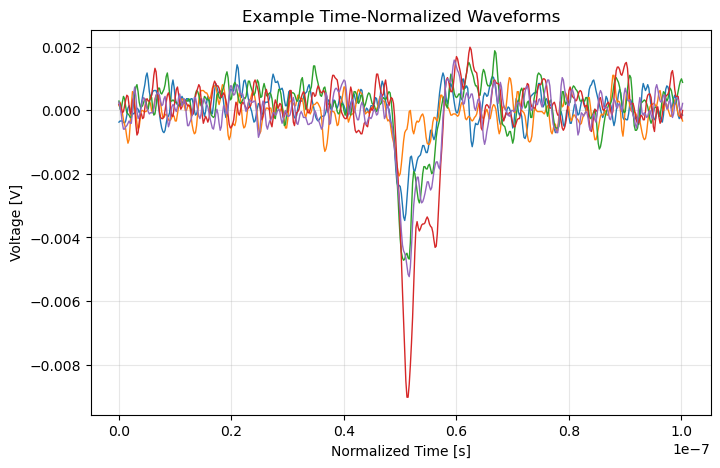

In [38]:
# -----------------------------
# Step 2: Time normalization
# -----------------------------
waveforms_norm = normalize_waveform_times(all_waveforms)

plt.figure(figsize=(8, 5))
for i in range(min(N_EXAMPLE_PLOTS, len(waveforms_norm))):
    t, v = waveforms_norm[i]
    plt.plot(t, v, lw=1)
plt.xlabel("Normalized Time [s]")
plt.ylabel("Voltage [V]")
plt.title("Example Time-Normalized Waveforms")
plt.grid(True, alpha=0.3)
plt.show()

## Baseline Subtraction

The baseline is estimated from the pre-pulse region `t < T_PRE_SIGNAL`. The mean of that region is subtracted from the whole waveform. The RMS/std of that same pre-pulse region is stored as the noise estimate `sigma` for each waveform.


In [39]:
# -----------------------------
# Step 3: Baseline subtraction
# -----------------------------
waveforms_bs, baselines, sigmas = subtract_baseline(
    waveforms_norm,
    t_pre_signal=T_PRE_SIGNAL
)

print(f"Mean baseline: {np.mean(baselines):.4e} V")
print(f"Mean sigma:    {np.mean(sigmas):.4e} V")

Mean baseline: 1.1818e-04 V
Mean sigma:    3.6633e-04 V


## Baseline-Subtracted Waveform Check

These traces show whether the baseline subtraction centered the pre-pulse region near zero. Large offsets or trends here indicate that the baseline window or file parsing should be checked.


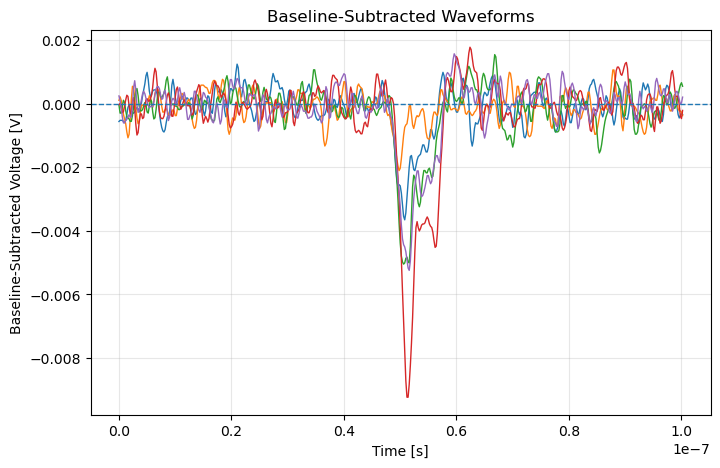

In [40]:
# Plot a few baseline-subtracted waveforms
plt.figure(figsize=(8, 5))
for i in range(min(N_EXAMPLE_PLOTS, len(waveforms_bs))):
    t, v = waveforms_bs[i]
    plt.plot(t, v, lw=1)
plt.axhline(0, ls="--", lw=1)
plt.xlabel("Time [s]")
plt.ylabel("Baseline-Subtracted Voltage [V]")
plt.title("Baseline-Subtracted Waveforms")
plt.grid(True, alpha=0.3)
plt.show()

## Average Baseline-Subtracted Waveform

The average waveform gives a quick view of the typical pulse timing and polarity across the dataset. It can also reveal systematic baseline offsets that are hard to see in individual traces.


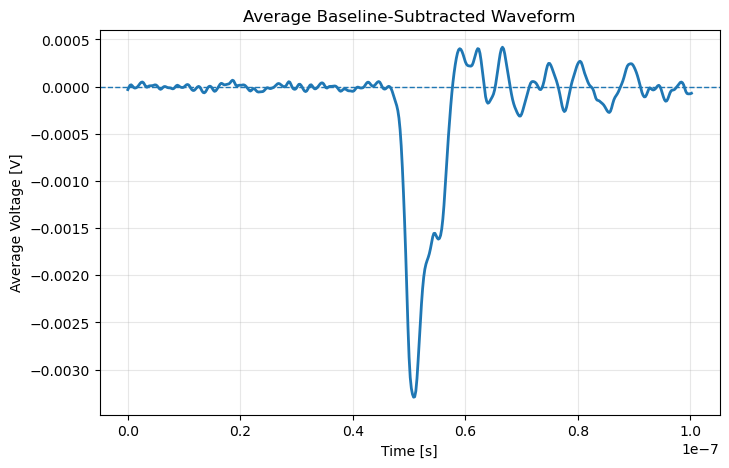

In [41]:
# Average waveform after baseline subtraction
min_len = min(len(t) for t, _ in waveforms_bs)
t_ref = waveforms_bs[0][0][:min_len]
v_stack = np.array([v[:min_len] for _, v in waveforms_bs])
v_avg = np.mean(v_stack, axis=0)

plt.figure(figsize=(8, 5))
plt.plot(t_ref, v_avg, lw=2)
plt.axhline(0, ls="--", lw=1)
plt.xlabel("Time [s]")
plt.ylabel("Average Voltage [V]")
plt.title("Average Baseline-Subtracted Waveform")
plt.grid(True, alpha=0.3)
plt.show()

## Optional Fourier Filtering

If `APPLY_FILTER` is true, each baseline-subtracted waveform is low-pass filtered in frequency space using `F_CUTOFF`. This can reduce high-frequency noise, but it can also slightly reshape fast pulses, so the before/after comparison should be checked.


In [42]:
# -----------------------------
# Step 4: Fourier filtering
# -----------------------------
if APPLY_FILTER:
    waveforms_proc = filter_waveforms(waveforms_bs, f_cut=F_CUTOFF)
else:
    waveforms_proc = waveforms_bs.copy()

## Filter Check

This overlay compares one baseline-subtracted waveform before and after filtering. The filtered trace should preserve the pulse shape while reducing unwanted high-frequency noise.


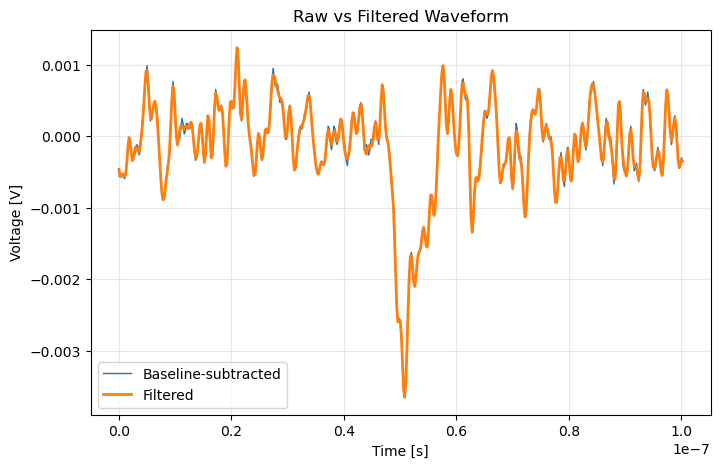

In [43]:
# Compare one waveform before and after filtering
t_raw, v_raw = waveforms_bs[0]
t_flt, v_flt = waveforms_proc[0]

plt.figure(figsize=(8, 5))
plt.plot(t_raw, v_raw, lw=1, label="Baseline-subtracted")
plt.plot(t_flt, v_flt, lw=2, label="Filtered")
plt.xlabel("Time [s]")
plt.ylabel("Voltage [V]")
plt.title("Raw vs Filtered Waveform")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Pulse Observables

The notebook defines pulse height as the magnitude of the most negative sample, `H = -min(v)`. It also computes a rough charge by integrating after `PULSE_START_TIME`. The more focused pulse-region charge is recomputed in the next section.


In [44]:
# -----------------------------
# Step 5/6: Pulse observables
# -----------------------------
H, Q, sigma_evt = extract_observables(
    waveforms_proc,
    sigmas,
    pulse_start_time=PULSE_START_TIME,
    R=R_TERMINATION
)

print(f"Mean pulse height: {np.nanmean(H):.4e} V")
print(f"Mean pulse charge: {np.nanmean(Q):.4e} C")

Mean pulse height: 4.0080e-03 V
Mean pulse charge: 3.1945e-13 C


## Pulse-Height Distribution

This histogram shows the distribution of pulse heights. The current version uses the full `H` array and fixed binning, so rare large pulses can stretch the x-axis. Adjust `set_xlim` if you want to zoom into the pedestal or SPE region without changing the data.


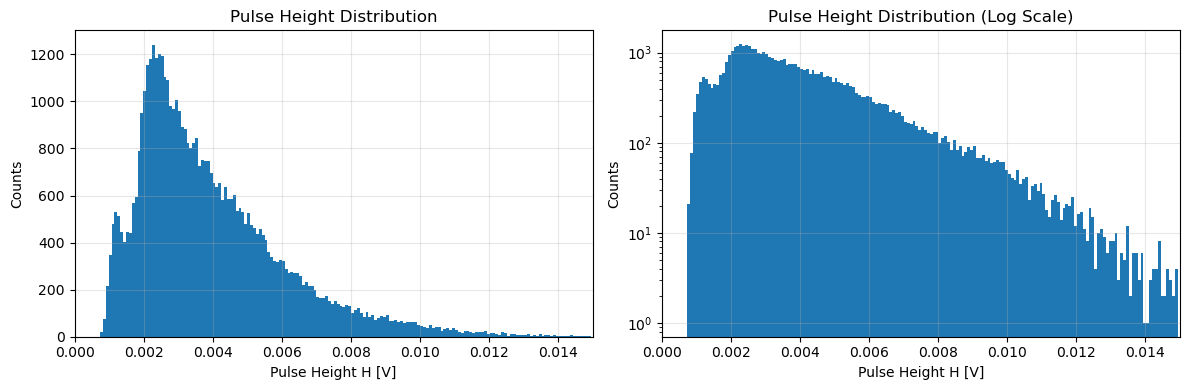

In [45]:
# -----------------------------
# Step 7: Pulse height distributions
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(H[np.isfinite(H)], bins=1000)
axes[0].set_xlabel("Pulse Height H [V]")
axes[0].set_xlim(0,.015)
axes[0].set_ylabel("Counts")
axes[0].set_title("Pulse Height Distribution")
axes[0].grid(True, alpha=0.3)

axes[1].hist(H[np.isfinite(H)], bins=1000, log=True)
axes[1].set_xlabel("Pulse Height H [V]")
axes[1].set_xlim(0,.015)
axes[1].set_ylabel("Counts")
axes[1].set_title("Pulse Height Distribution (Log Scale)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Pulse-Height Threshold

`sigma_mean` is the average RMS noise measured in the pre-pulse baseline windows. The voltage threshold is `V_thr = THRESHOLD_SIGMA * sigma_mean`, and waveforms with `H > V_thr` are treated as accepted pulse candidates.


In [46]:
# -----------------------------
# Step 8: Voltage threshold from baseline noise
# -----------------------------
sigma_mean = np.nanmean(sigma_evt)
V_thr = THRESHOLD_SIGMA * sigma_mean
height_pass = np.isfinite(H) & (H > V_thr)

print(f"Mean baseline noise sigma      = {sigma_mean:.4e} V")
print(f"Voltage threshold ({THRESHOLD_SIGMA:.1f}σ) = {V_thr:.4e} V")
print(f"Pulses passing H > V_thr       = {np.sum(height_pass)} / {len(H)}")

Mean baseline noise sigma      = 3.6633e-04 V
Voltage threshold (5.0σ) = 1.8316e-03 V
Pulses passing H > V_thr       = 44282 / 49500


## Threshold Visualization

This plot overlays the height threshold on the pulse-height distribution. Pulses to the right of the threshold pass the height cut; pulses below it are rejected as noise-like by this simple selection.


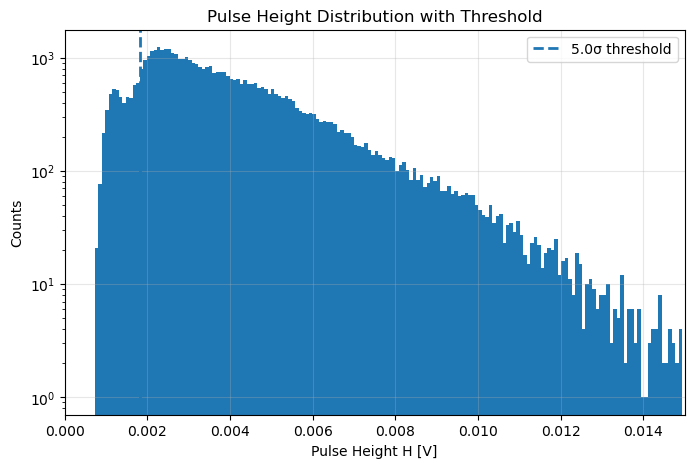

In [47]:
# Pulse height distribution with threshold marked
plt.figure(figsize=(8, 5))
plt.hist(H[np.isfinite(H)], bins=1000, log=True)
plt.axvline(V_thr, ls="--", lw=2, label=f"{THRESHOLD_SIGMA:.1f}σ threshold")
plt.xlabel("Pulse Height H [V]")
plt.xlim(0,.015)
plt.ylabel("Counts")
plt.title("Pulse Height Distribution with Threshold")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## Pulse-Region Charge Integration

`integrate_pulse_region` finds the most negative point after `PULSE_START_TIME` and integrates only the negative-going region around that pulse. This avoids integrating a long baseline interval and gives the `Q_region` values used for charge selection.


In [48]:
# -----------------------------
# Step 8.1: Recompute charge using the pulse region only
# -----------------------------
def integrate_pulse_region(t, v, R=50.0, pulse_start_time=20e-9):
    if len(t) < 3:
        return np.nan, np.nan, np.nan

    search_mask = t >= pulse_start_time
    if np.sum(search_mask) < 3:
        search_mask = np.ones_like(t, dtype=bool)

    idx_candidates = np.where(search_mask)[0]
    idx_min_local = np.argmin(v[search_mask])
    idx_min = idx_candidates[idx_min_local]

    # Skip waveforms that do not contain a negative-going pulse
    if v[idx_min] >= 0:
        return 0.0, t[idx_min], t[idx_min]

    i_left = idx_min
    while i_left > 0 and v[i_left] < 0:
        i_left -= 1

    i_right = idx_min
    while i_right < len(v) - 1 and v[i_right] < 0:
        i_right += 1

    if i_right <= i_left:
        return np.nan, np.nan, np.nan

    q = (1.0 / R) * np.trapezoid(-v[i_left:i_right+1], t[i_left:i_right+1])
    return q, t[i_left], t[i_right]


Q_region = []
t_left = []
t_right = []

for t, v in waveforms_proc:
    q_i, tl_i, tr_i = integrate_pulse_region(
        t, v, R=R_TERMINATION, pulse_start_time=PULSE_START_TIME
    )
    Q_region.append(q_i)
    t_left.append(tl_i)
    t_right.append(tr_i)

Q_region = np.array(Q_region)
t_left = np.array(t_left)
t_right = np.array(t_right)

valid_q = np.isfinite(Q_region)
print(f"Mean pulse-region charge = {np.nanmean(Q_region):.4e} C")
print(f"Waveforms with valid pulse-region charge = {np.sum(valid_q)} / {len(Q_region)}")

Mean pulse-region charge = 3.4949e-13 C
Waveforms with valid pulse-region charge = 49500 / 49500


## Charge Window Check

These plots show the integration bounds for a few waveforms. Use them to verify that the zero-crossing pulse window is selecting the actual pulse and not a baseline fluctuation.


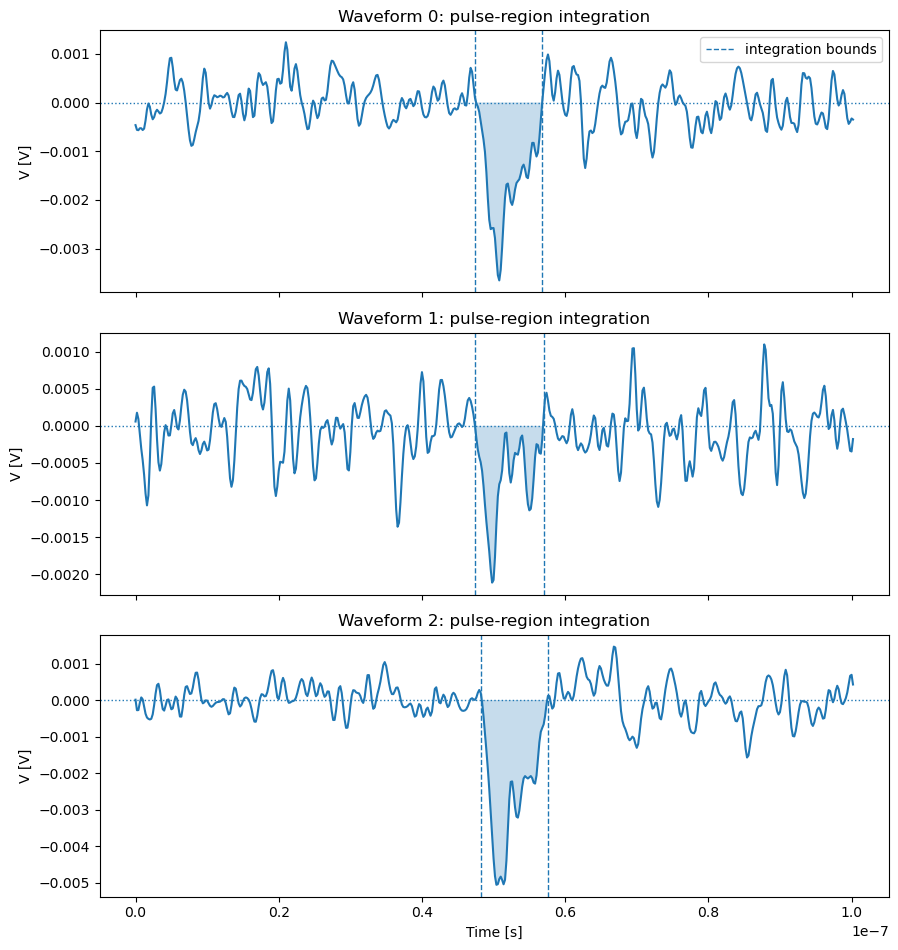

In [49]:
# Inspect a few pulse windows used for the charge integral
n_show = min(3, len(waveforms_proc))
fig, axes = plt.subplots(n_show, 1, figsize=(9, 3.2 * n_show), sharex=True)

if n_show == 1:
    axes = [axes]

for ax, i in zip(axes, range(n_show)):
    t, v = waveforms_proc[i]
    ax.plot(t, v, lw=1.5)
    if np.isfinite(t_left[i]):
        ax.axvline(t_left[i], ls="--", lw=1, label="integration bounds" if i == 0 else None)
        ax.axvline(t_right[i], ls="--", lw=1)
        mask_int = (t >= t_left[i]) & (t <= t_right[i])
        ax.fill_between(t[mask_int], v[mask_int], 0, alpha=0.25)
    ax.axhline(0, ls=":", lw=1)
    ax.set_ylabel("V [V]")
    ax.set_title(f"Waveform {i}: pulse-region integration")

axes[-1].set_xlabel("Time [s]")
handles, labels = axes[0].get_legend_handles_labels()
if labels:
    axes[0].legend()
plt.tight_layout()
plt.show()

## Integrated Charge Distribution

This charge histogram compares all pulse-region charges with the subset that passed the pulse-height threshold. `Qc` is chosen from the low percentile of the height-selected charges and is used as a second charge cut.


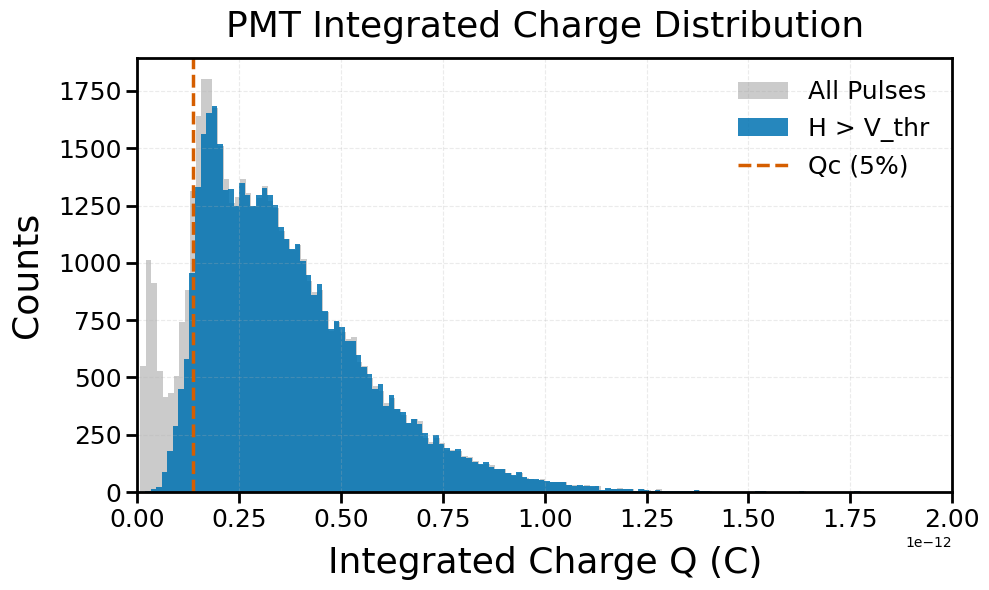

Charge threshold Qc (5th percentile of H > V_thr charges) = 1.3701e-13 C


In [50]:
# -----------------------------
# Step 8.2: Integrated charge distribution (poster version)
# -----------------------------
accepted_charge_from_height = Q_region[height_pass & np.isfinite(Q_region)]
all_charges = Q_region[np.isfinite(Q_region)]

# Compute threshold
QC_PERCENTILE = 5
Qc = np.nanpercentile(accepted_charge_from_height, QC_PERCENTILE) if len(accepted_charge_from_height) else np.nan

# Plot
plt.figure(figsize=(10, 6))

# Histograms (clean colors, solid contrast)
plt.hist(
    all_charges,
    bins=1000,
    alpha=0.5,
    color="#999999",
    label="All Pulses"
)

plt.hist(
    accepted_charge_from_height,
    bins=1000,
    alpha=0.85,
    color="#0072B2",
    label="H > V_thr"
)

# Threshold line (important visual anchor)
if np.isfinite(Qc):
    plt.axvline(
        Qc,
        color="#D55E00",
        linestyle="--",
        linewidth=2.5,
        label=f"Qc ({QC_PERCENTILE}%)"
    )

# Labels (poster-sized)
plt.xlabel("Integrated Charge Q (C)", fontsize=26, labelpad=10)
plt.ylabel("Counts", fontsize=26, labelpad=10)

# Title
plt.title("PMT Integrated Charge Distribution", fontsize=26, pad=15)

# Axis styling
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(2)

plt.tick_params(
    axis='both',
    which='major',
    labelsize=18,
    width=2,
    length=8
)
plt.tick_params(
    axis='both',
    which='minor',
    width=1.5,
    length=4
)
plt.xlim(0,.2e-11)

# Grid (subtle)
plt.grid(True, linestyle="--", alpha=0.25)

# Legend
plt.legend(frameon=False, fontsize=18)

plt.tight_layout()
plt.show()

print(f"Charge threshold Qc ({QC_PERCENTILE}th percentile of H > V_thr charges) = {Qc:.4e} C")

## Charge Threshold Check

This plot shows the integrated-charge distribution with `Qc` marked. Waveforms with `Q_region >= Qc` pass the charge cut and are used in the final accepted-pulse statistics.


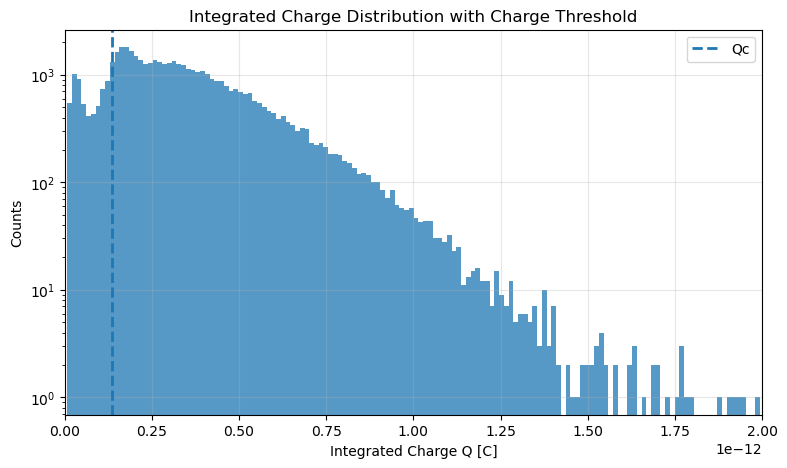

Pulses passing Q >= Qc = 42881 / 49500


In [51]:
# Show the charge distribution again with Qc marked
charge_pass = np.isfinite(Q_region) & (Q_region >= Qc)

plt.figure(figsize=(9, 5))
plt.hist(Q_region[np.isfinite(Q_region)], bins=1000, log=True, alpha=0.75)
plt.axvline(Qc, ls="--", lw=2, label="Qc")
plt.xlabel("Integrated Charge Q [C]")
plt.xlim(0,.2e-11)
plt.ylabel("Counts")
plt.title("Integrated Charge Distribution with Charge Threshold")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Pulses passing Q >= Qc = {np.sum(charge_pass)} / {len(Q_region)}")

## Accepted-Pulse Statistics and Physics Conversion

The final accepted pulses are those passing the charge cut. The notebook computes the accepted-pulse rate, mean accepted charge, average anode current, and approximate photon quantities using the configured PMT gain and quantum efficiency.


In [52]:
# -----------------------------
# Steps 9-13: Accepted-pulse statistics and physics conversion
# -----------------------------
E_CHARGE = 1.602176634e-19  # C
PMT_GAIN = 1e4           
QE = 0.06                   

durations = waveform_duration(waveforms_proc)
T_window = np.nanmean(durations)
N_waveforms = len(waveforms_proc)
T_total = N_waveforms * T_window

Q_acc = Q_region[charge_pass]
N_acc = len(Q_acc)
Q_mean_acc = np.nanmean(Q_acc) if N_acc else np.nan
R_acc = N_acc / T_total if T_total > 0 else np.nan
I_avg_acc = np.nansum(Q_acc) / T_total if T_total > 0 else np.nan

n_e_mean = Q_mean_acc / (E_CHARGE * PMT_GAIN) if np.isfinite(Q_mean_acc) else np.nan
n_e_thr = Qc / (E_CHARGE * PMT_GAIN) if np.isfinite(Qc) else np.nan
N_ph_mean = n_e_mean / QE if np.isfinite(n_e_mean) else np.nan
photon_flux = R_acc * N_ph_mean if np.isfinite(R_acc) and np.isfinite(N_ph_mean) else np.nan

print(f"Mean waveform window          = {T_window:.4e} s")
print(f"Total observation time        = {T_total:.4e} s")
print(f"Accepted pulses N_acc         = {N_acc}")
print(f"Accepted pulse rate R_acc     = {R_acc:.4e} Hz")
print(f"Mean accepted charge <Q>      = {Q_mean_acc:.4e} C")
print(f"Threshold charge Qc           = {Qc:.4e} C")
print(f"Threshold anode electrons     = {n_e_thr:.4e}")
print(f"Mean anode electrons / pulse  = {n_e_mean:.4e}")
print(f"Mean photons / pulse          = {N_ph_mean:.4e}")
print(f"Photon flux                  = {photon_flux:.4e} photons/s")
print(f"Average anode current         = {I_avg_acc:.4e} A")
print(f"Average anode current         = {I_avg_acc*1e9:.4e} nA")

Mean waveform window          = 1.0020e-07 s
Total observation time        = 4.9599e-03 s
Accepted pulses N_acc         = 42881
Accepted pulse rate R_acc     = 8.6455e+06 Hz
Mean accepted charge <Q>      = 3.9195e-13 C
Threshold charge Qc           = 1.3701e-13 C
Threshold anode electrons     = 8.5517e+01
Mean anode electrons / pulse  = 2.4464e+02
Mean photons / pulse          = 4.0773e+03
Photon flux                  = 3.5250e+10 photons/s
Average anode current         = 3.3886e-06 A
Average anode current         = 3.3886e+03 nA


## Final Summary

This block prints the main scalar outputs in one place: waveform counts, thresholds, accepted-pulse counts, accepted rate, charge values, estimated photons, and average current.


In [53]:
# -----------------------------
# Step 14: Final summary block
# -----------------------------
summary = {
    "Number of waveforms": N_waveforms,
    "Mean waveform window [s]": T_window,
    "Total observation time [s]": T_total,
    "Mean noise sigma [V]": sigma_mean,
    "Voltage threshold V_thr [V]": V_thr,
    "Height-selected pulses": int(np.sum(height_pass)),
    "Charge threshold Qc [C]": Qc,
    "Accepted pulses N_acc": int(N_acc),
    "Accepted pulse rate R_acc [Hz]": R_acc,
    "Mean accepted charge <Q> [C]": Q_mean_acc,
    "Threshold anode electrons": n_e_thr,
    "Mean anode electrons / pulse": n_e_mean,
    "Mean photons / pulse": N_ph_mean,
    "Photon flux [photons/s]": photon_flux,
    "Average anode current [A]": I_avg_acc,
    "Average anode current [nA]": I_avg_acc * 1e9,
}

print("========== FINAL RESULTS ==========")
for key, value in summary.items():
    if isinstance(value, (int, np.integer)):
        print(f"{key:30s}: {value}")
    else:
        print(f"{key:30s}: {value:.4e}")

========== FINAL RESULTS ==========
Number of waveforms           : 49500
Mean waveform window [s]      : 1.0020e-07
Total observation time [s]    : 4.9599e-03
Mean noise sigma [V]          : 3.6633e-04
Voltage threshold V_thr [V]   : 1.8316e-03
Height-selected pulses        : 44282
Charge threshold Qc [C]       : 1.3701e-13
Accepted pulses N_acc         : 42881
Accepted pulse rate R_acc [Hz]: 8.6455e+06
Mean accepted charge <Q> [C]  : 3.9195e-13
Threshold anode electrons     : 8.5517e+01
Mean anode electrons / pulse  : 2.4464e+02
Mean photons / pulse          : 4.0773e+03
Photon flux [photons/s]       : 3.5250e+10
Average anode current [A]     : 3.3886e-06
Average anode current [nA]    : 3.3886e+03


## Charge vs Height Diagnostic

This scatter plot checks whether pulse height and integrated charge are correlated. Outliers here can reveal bad integrations, saturated pulses, or baseline artifacts.


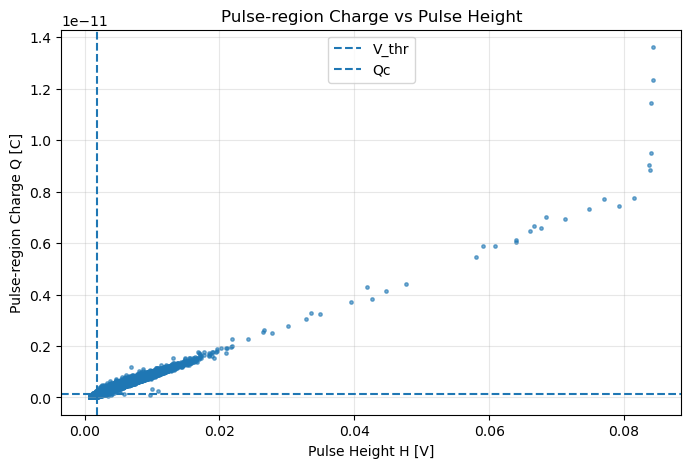

In [54]:
# Pulse charge vs pulse height
valid = np.isfinite(H) & np.isfinite(Q_region)

plt.figure(figsize=(8, 5))
plt.scatter(H[valid], Q_region[valid], s=6, alpha=0.6)
plt.axvline(V_thr, ls="--", lw=1.5, label="V_thr")
plt.axhline(Qc, ls="--", lw=1.5, label="Qc")
plt.xlabel("Pulse Height H [V]")
plt.ylabel("Pulse-region Charge Q [C]")
plt.title("Pulse-region Charge vs Pulse Height")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [55]:
print(np.argmax(Q_region[valid]))

15339


## Rejected-Waveform Examples

This final diagnostic plots example waveforms rejected by the pulse-height threshold. It is useful for checking whether the rejected set really looks noise-like or whether the threshold is discarding real small pulses.


Rejected by H <= V_thr: 5218 / 49500


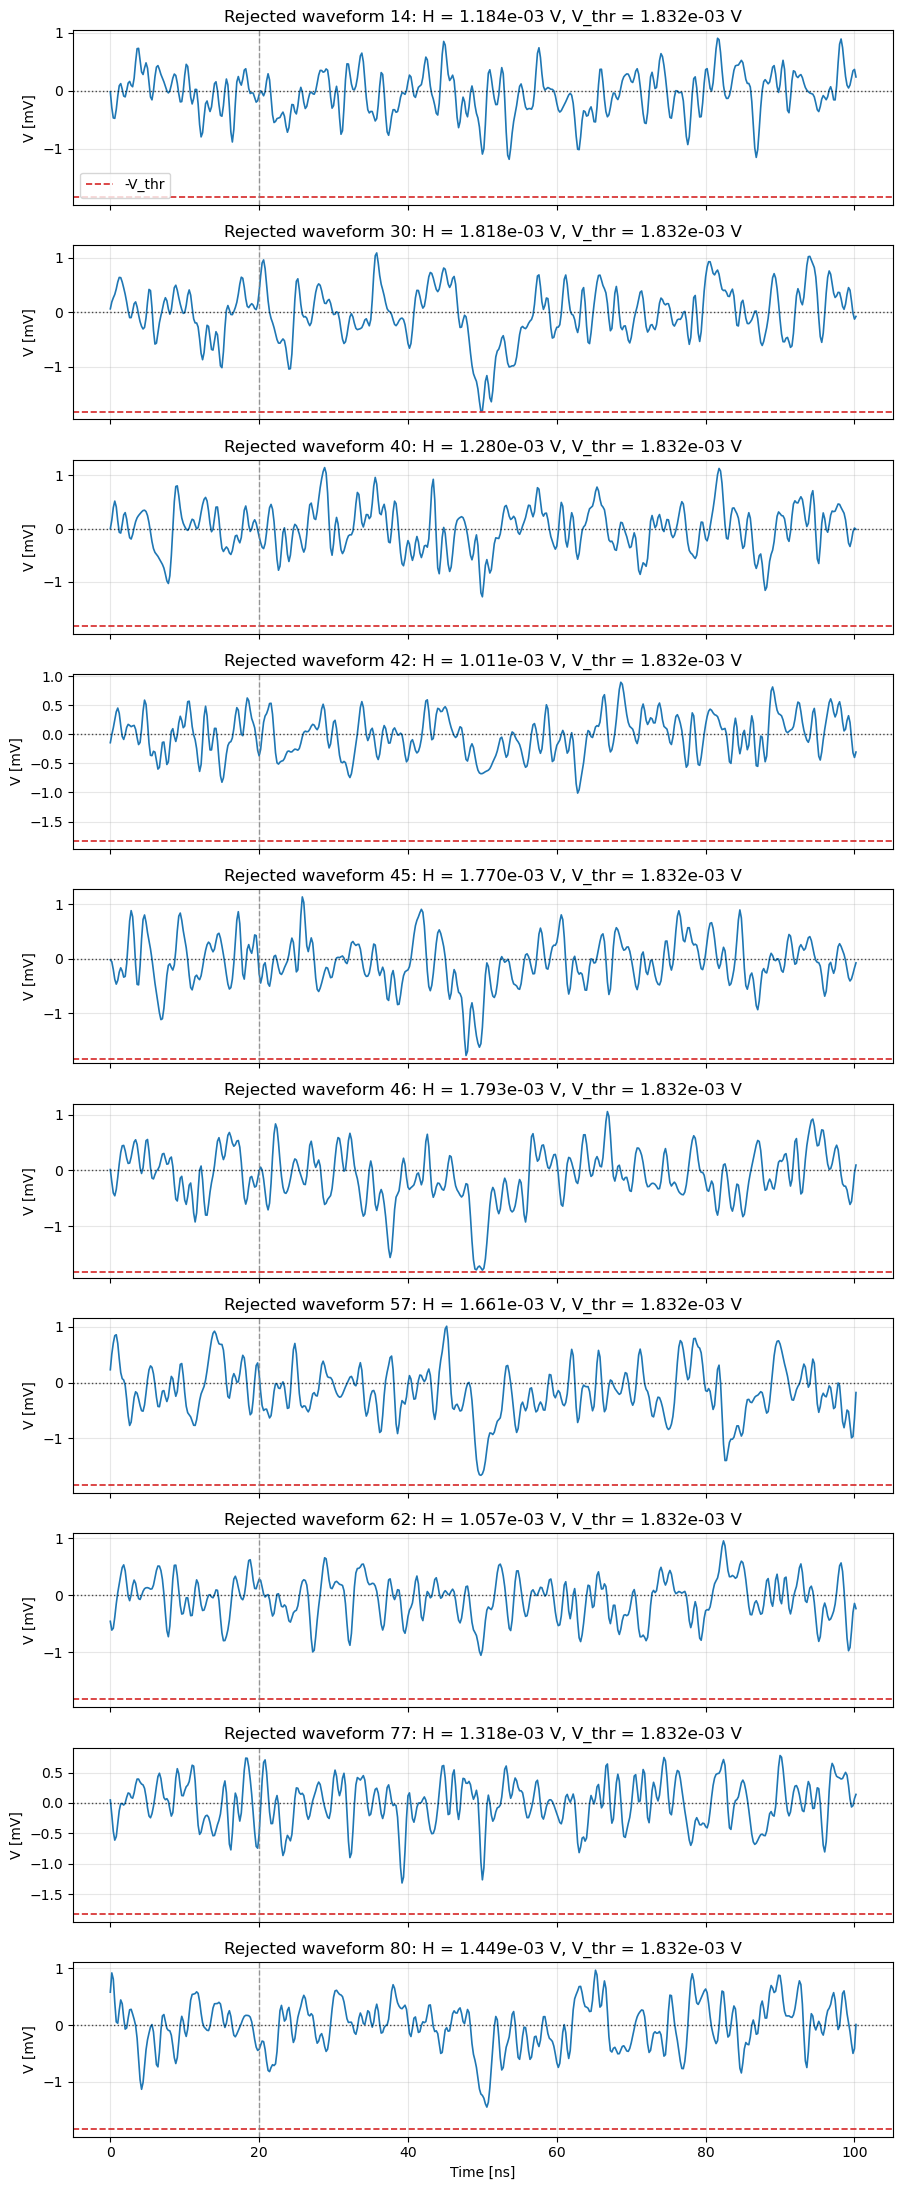

In [56]:
# -----------------------------
# Final check: examples rejected by the pulse-height threshold
# -----------------------------
rejected_idx = np.where(~height_pass & np.isfinite(H))[0]
n_rejected_show = min(10, len(rejected_idx))

print(f"Rejected by H <= V_thr: {len(rejected_idx)} / {len(H)}")

if n_rejected_show == 0:
    print("No rejected waveforms to plot.")
else:
    fig, axes = plt.subplots(n_rejected_show, 1, figsize=(9, 2.2 * n_rejected_show), sharex=True)

    if n_rejected_show == 1:
        axes = [axes]

    for ax, idx in zip(axes, rejected_idx[:n_rejected_show]):
        t, v = waveforms_proc[idx]
        ax.plot(t * 1e9, v * 1e3, lw=1.2)
        ax.axhline(0, ls=":", lw=1, color="black", alpha=0.7)
        ax.axhline(-V_thr * 1e3, ls="--", lw=1.2, color="tab:red", label="-V_thr")
        ax.axvline(PULSE_START_TIME * 1e9, ls="--", lw=1, color="tab:gray", alpha=0.8)
        ax.set_ylabel("V [mV]")
        ax.set_title(f"Rejected waveform {idx}: H = {H[idx]:.3e} V, V_thr = {V_thr:.3e} V")
        ax.grid(True, alpha=0.3)

    axes[0].legend()
    axes[-1].set_xlabel("Time [ns]")
    plt.tight_layout()
    plt.show()
